# Phase 0 & Phase 1: Data Preprocessing & Deep EDA

**Pipeline**: Vietnamese Financial News RAG System — v2  
**Sections covered**: §0.4 Model Verification · §1.1 Load & Validate · §1.2 Cleaning · §1.3 EDA (8 sections) · §1.4 EDA Report · §1.5 Idempotent Save

**How to run**:
- **Local**: `jupyter notebook` from `implementation/`
- **Colab**: Mount Drive first (Cell 0), then run top-to-bottom

All cells are idempotent — safe to re-run without recomputing completed work.

## Cell 0 — Environment Setup

In [1]:
import os, sys
from pathlib import Path

# ── Detect environment ──────────────────────────────────────────────────────
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IN_COLAB = is_colab()
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")

# ── Mount Drive (Colab only) ────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = Path('/content/rag-vn-finance/implementation')
    # Clone repo if not already present
    if not REPO_ROOT.exists():
        print("Cloning repo...")
        os.system('git clone https://github.com/<your-repo>/rag-vn-finance /content/rag-vn-finance')
else:
    # Local: this notebook lives at implementation/notebooks/
    REPO_ROOT = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path.cwd().parent
    # Fallback: hardcode relative to notebook location
    REPO_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())

print(f"Project root: {REPO_ROOT}")
assert REPO_ROOT.exists(), f"Project root not found: {REPO_ROOT}"

# ── Add src/ to path ────────────────────────────────────────────────────────
src_path = str(REPO_ROOT)
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f"sys.path: {sys.path[:3]}")

# ── Install dependencies if needed (Colab) ──────────────────────────────────
if IN_COLAB:
    req_path = REPO_ROOT / 'requirements.txt'
    if req_path.exists():
        os.system(f'pip install -r {req_path} -q')
        print("Dependencies installed.")
    else:
        print("WARNING: requirements.txt not found — install manually")

print("\nCell 0 complete.")

Environment: Local
Project root: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation
sys.path: ['d:\\000MINHTHONG\\Junior - Semester II\\TDM & A\\FinalProject\\finance-news\\implementation', 'C:\\Users\\Inspiron\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\Inspiron\\AppData\\Local\\Programs\\Python\\Python311\\DLLs']

Cell 0 complete.


## Cell 0b — Phase 0: Model Verification (§0.4)

> Run once at Phase 0. Requires OPENROUTER_API_KEY and GROQ_API_KEY in `.env` or Colab userdata.

In [2]:
from src.utils import load_config, get_env, resolve_path

config = load_config(REPO_ROOT / 'configs' / 'config.yaml')
print("Config loaded.")

OPENROUTER_KEY = get_env('OPENROUTER_API_KEY')
GROQ_KEY   = get_env('GROQ_API_KEY')

# ---- VERIFY OPENROUTER ----
if not OPENROUTER_KEY:
    print("WARNING: OPENROUTER_API_KEY not found — skipping OpenRouter verification")
else:
    try:
        from openai import OpenAI
        
        client = OpenAI(
            base_url="https://openrouter.ai/api/v1",
            api_key=OPENROUTER_KEY
        )
        
        target_model = config['generation']['model']
        print(f"Verifying OpenRouter model: {target_model}...")
        # Lightweight call to verify connection and key
        models = client.models.list()
        available = [m.id for m in models.data]
        if target_model in available:
            print(f"\n✅ {target_model} confirmed active on OpenRouter")
        else:
            print(f"\n⚠️  {target_model} NOT found — update config.yaml generation.model")
    except ImportError:
        print("⚠️  Error: 'openai' library not installed. Check requirements.txt")
    except Exception as e:
        print(f"⚠️  OpenRouter verification failed: {e}")

# ---- VERIFY GROQ ----
if not GROQ_KEY:
    print("WARNING: GROQ_API_KEY not found — skipping Groq verification")
else:
    try:
        from groq import Groq
        client_groq = Groq(api_key=GROQ_KEY)
        models = [m.id for m in client_groq.models.list().data]
        target_groq = config['evaluation']['groq_model']
        if target_groq in models:
            print(f"✅ {target_groq} confirmed active")
        else:
            print(f"⚠️  {target_groq} not found. Available Groq models:")
            for m in models:
                print(f"   - {m}")
            print("Update config.yaml evaluation.groq_model before Phase 8.")
    except ImportError:
        print("⚠️  Lỗi: Thư viện 'groq' chưa được cài đặt. Hãy kiểm tra lại requirements.txt")
    except Exception as e:
        print(f"⚠️  Groq verification failed: {e}")

print("\nCell 0b complete.")


Config loaded.
Verifying OpenRouter model: google/gemma-4-31b-it:free...

✅ google/gemma-4-31b-it:free confirmed active on OpenRouter
✅ llama-3.3-70b-versatile confirmed active

Cell 0b complete.


## Cell 1 — Load & Schema Validation (§1.1)

In [3]:
import pandas as pd
from src.utils import load_config, resolve_path
from src.preprocessing import load_and_validate

config = load_config(REPO_ROOT / 'configs' / 'config.yaml')

raw_path = resolve_path(config['data'], 'raw_path')
# Make path absolute relative to REPO_ROOT if not absolute
if not os.path.isabs(raw_path):
    raw_path = str(REPO_ROOT / raw_path)

print(f"Loading from: {raw_path}")
df_raw = load_and_validate(raw_path)

print(f"\nShape: {df_raw.shape}")
print(f"\nColumn dtypes:\n{df_raw.dtypes}")
print(f"\nFirst 3 rows:")
display(df_raw.head(3))

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cpu
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[2026-05-06 13:58:17] [INFO] src.preprocessing: Loading data from: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\raw\financial_news_10k.csv
Loading data from: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\raw\financial_news_10k.csv


Loading from: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\raw\financial_news_10k.csv


[2026-05-06 13:58:18] [INFO] src.preprocessing: Schema OK. Shape: (10000, 7)
Schema OK. Shape: (10000, 7)
[2026-05-06 13:58:18] [INFO] src.preprocessing: Dtypes:
url                     object
title                   object
time                    object
category                object
content                 object
tags                    object
content_token_counts     int64
dtype: object
Dtypes:
url                     object
title                   object
time                    object
category                object
content                 object
tags                    object
content_token_counts     int64
dtype: object



Shape: (10000, 7)

Column dtypes:
url                     object
title                   object
time                    object
category                object
content                 object
tags                    object
content_token_counts     int64
dtype: object

First 3 rows:


,url,title,time,category,content,tags,content_token_counts
0,https://vneconomy.vn/hang-ve-tranh-ban-thi-tru...,"Hàng về tranh bán, thị trường chìm trong sắc đ...",2023-03-03,Chứng khoán,"Biên độ tăng 15,87 điểm hôm 1/3 đã bị quét sạc...",nhận định chứng khoán,919
1,https://vneconomy.vn/bo-tai-chinh-lay-y-kien-d...,Bộ Tài chính lấy ý kiến đề xuất ưu đãi thuế th...,2024-06-13,Tài chính,"Theo Bộ Tài chính, mục tiêu đề xuất ưu đãi thu...","Bộ Tài Chính, doanh nghiệp, doanh nghiệp khoa ...",892
2,https://baodautu.vn/panasonic-khai-truong-nha-...,Panasonic khai trương nhà máy mới về thiết bị ...,2021-09-30,Doanh nghiệp,Nhà máy sẽ bắt đầu sản xuất quạt trần và quạt ...,"thiết bị chất lượng không khí, Panasonic Việt ...",600


## Cell 2 — Cleaning Pipeline (§1.2)

In [4]:
from src.preprocessing import clean_pipeline

drop_log_path = resolve_path(config['data'], 'drop_log_path')
if not os.path.isabs(drop_log_path):
    drop_log_path = str(REPO_ROOT / drop_log_path)

df = clean_pipeline(df_raw.copy(), drop_log_path=drop_log_path)

print(f"\nCleaning summary:")
print(f"  Raw rows  : {len(df_raw):,}")
print(f"  Clean rows: {len(df):,}")
print(f"  Dropped   : {len(df_raw) - len(df):,}")
print(f"\nNew columns added: {[c for c in df.columns if c not in df_raw.columns]}")
print(f"\nSource distribution (derived from URL):")
print(df['source'].value_counts())
print(f"\nYear range: {df['year'].min()} – {df['year'].max()}")

[2026-05-06 13:58:19] [INFO] src.preprocessing: Step 1 — Dropped 0 duplicate URLs
Step 1 — Dropped 0 duplicate URLs
[2026-05-06 13:58:19] [INFO] src.preprocessing: Step 2 — Dropped 1 rows (null/short content)
Step 2 — Dropped 1 rows (null/short content)


[2026-05-06 13:58:19] [INFO] src.preprocessing: Step 3 — Parsed time column, dropped 0 unparseable rows
Step 3 — Parsed time column, dropped 0 unparseable rows
[2026-05-06 13:58:29] [INFO] src.preprocessing: Drop log saved to d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\drop_log.csv — total dropped: 1/10000
Drop log saved to d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\drop_log.csv — total dropped: 1/10000
[2026-05-06 13:58:29] [INFO] src.preprocessing: Applying Semantic Enrichment...
Applying Semantic Enrichment...
[2026-05-06 16:17:34] [INFO] src.preprocessing: Cleaning complete. Final shape: (9999, 16)
Cleaning complete. Final shape: (9999, 16)



Cleaning summary:
  Raw rows  : 10,000
  Clean rows: 9,999
  Dropped   : 1

New columns added: ['year', 'month', 'yearmonth', 'doc_id', 'source', 'tickers', 'is_historical', 'numerical_density', 'entities']

Source distribution (derived from URL):
source
vneconomy.vn    5065
baodautu.vn     4934
Name: count, dtype: int64

Year range: 2015 – 2025


## Cell 3 — EDA-1: Source & Temporal Coverage (§1.3)

[2026-05-06 16:17:35] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda1_source_temporal.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda1_source_temporal.png


EDA-1 Results:
{
  "source_distribution": {
    "vneconomy.vn": 5065,
    "baodautu.vn": 4934
  },
  "year_distribution": {
    "2015": 483,
    "2016": 494,
    "2017": 533,
    "2018": 510,
    "2019": 493,
    "2020": 472,
    "2021": 1398,
    "2022": 1685,
    "2023": 1547,
    "2024": 1707,
    "2025": 677
  },
  "dead_months_lt10_articles": 0,
  "design_implication": "QA generation in Phase 5 must stratify by year AND source to avoid 2021-2024 overrepresentation."
}


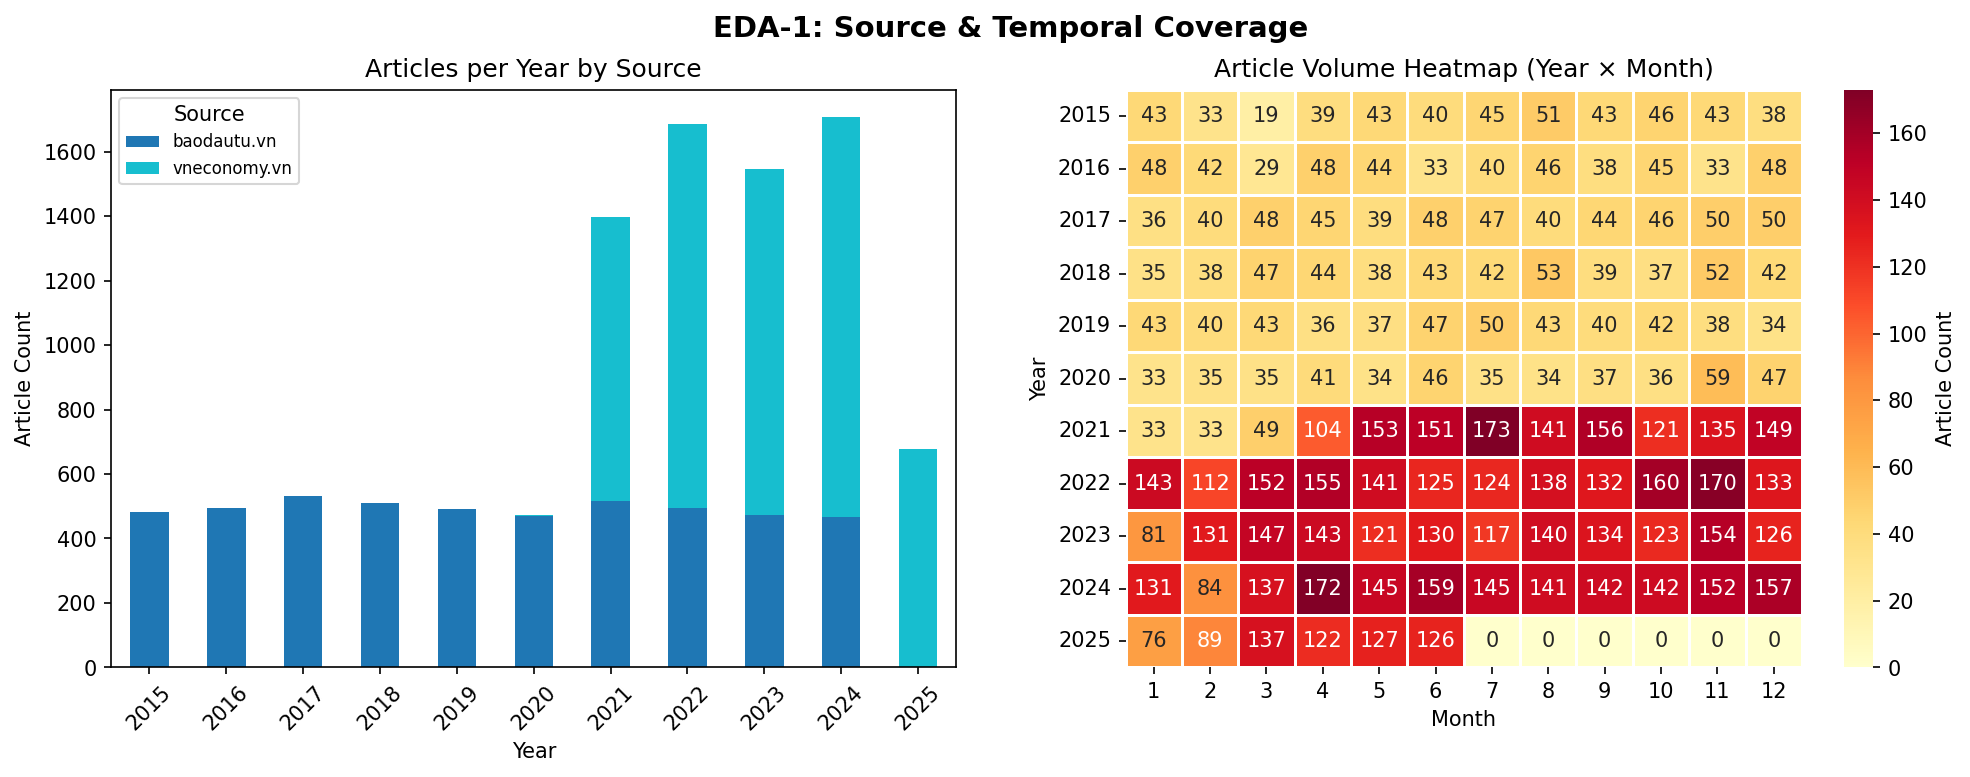

In [5]:
from src.preprocessing import eda_source_temporal
import json

plots_dir = resolve_path(config['data'], 'eda_plots_dir')
if not os.path.isabs(plots_dir):
    plots_dir = str(REPO_ROOT / plots_dir)

eda1 = eda_source_temporal(df, plots_dir)

print("EDA-1 Results:")
print(json.dumps(eda1, indent=2, ensure_ascii=False))

from IPython.display import Image, display as ipy_display
ipy_display(Image(filename=os.path.join(plots_dir, 'eda1_source_temporal.png'), width=900))

## Cell 4 — EDA-2: Category Distribution (§1.3)

[2026-05-06 16:17:37] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda2_category.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda2_category.png


EDA-2 Results:
{
  "category_distribution": {
    "Doanh nghiệp": 1748,
    "Đầu tư": 1479,
    "Chứng khoán": 1200,
    "Ngân hàng - Bảo hiểm": 813,
    "Bất động sản": 743,
    "Thế giới": 665,
    "Tài chính - Chứng khoán": 580,
    "Tài chính": 579,
    "Dự án - quy hoạch": 569,
    "Thị trường": 511,
    "Kinh tế số": 457,
    "Chuyển động thị trường": 339,
    "Thông tin doanh nghiệp": 316
  },
  "under_represented_categories": [],
  "design_implication": "Retrieval evaluation should report metrics per category to detect per-domain performance gaps."
}


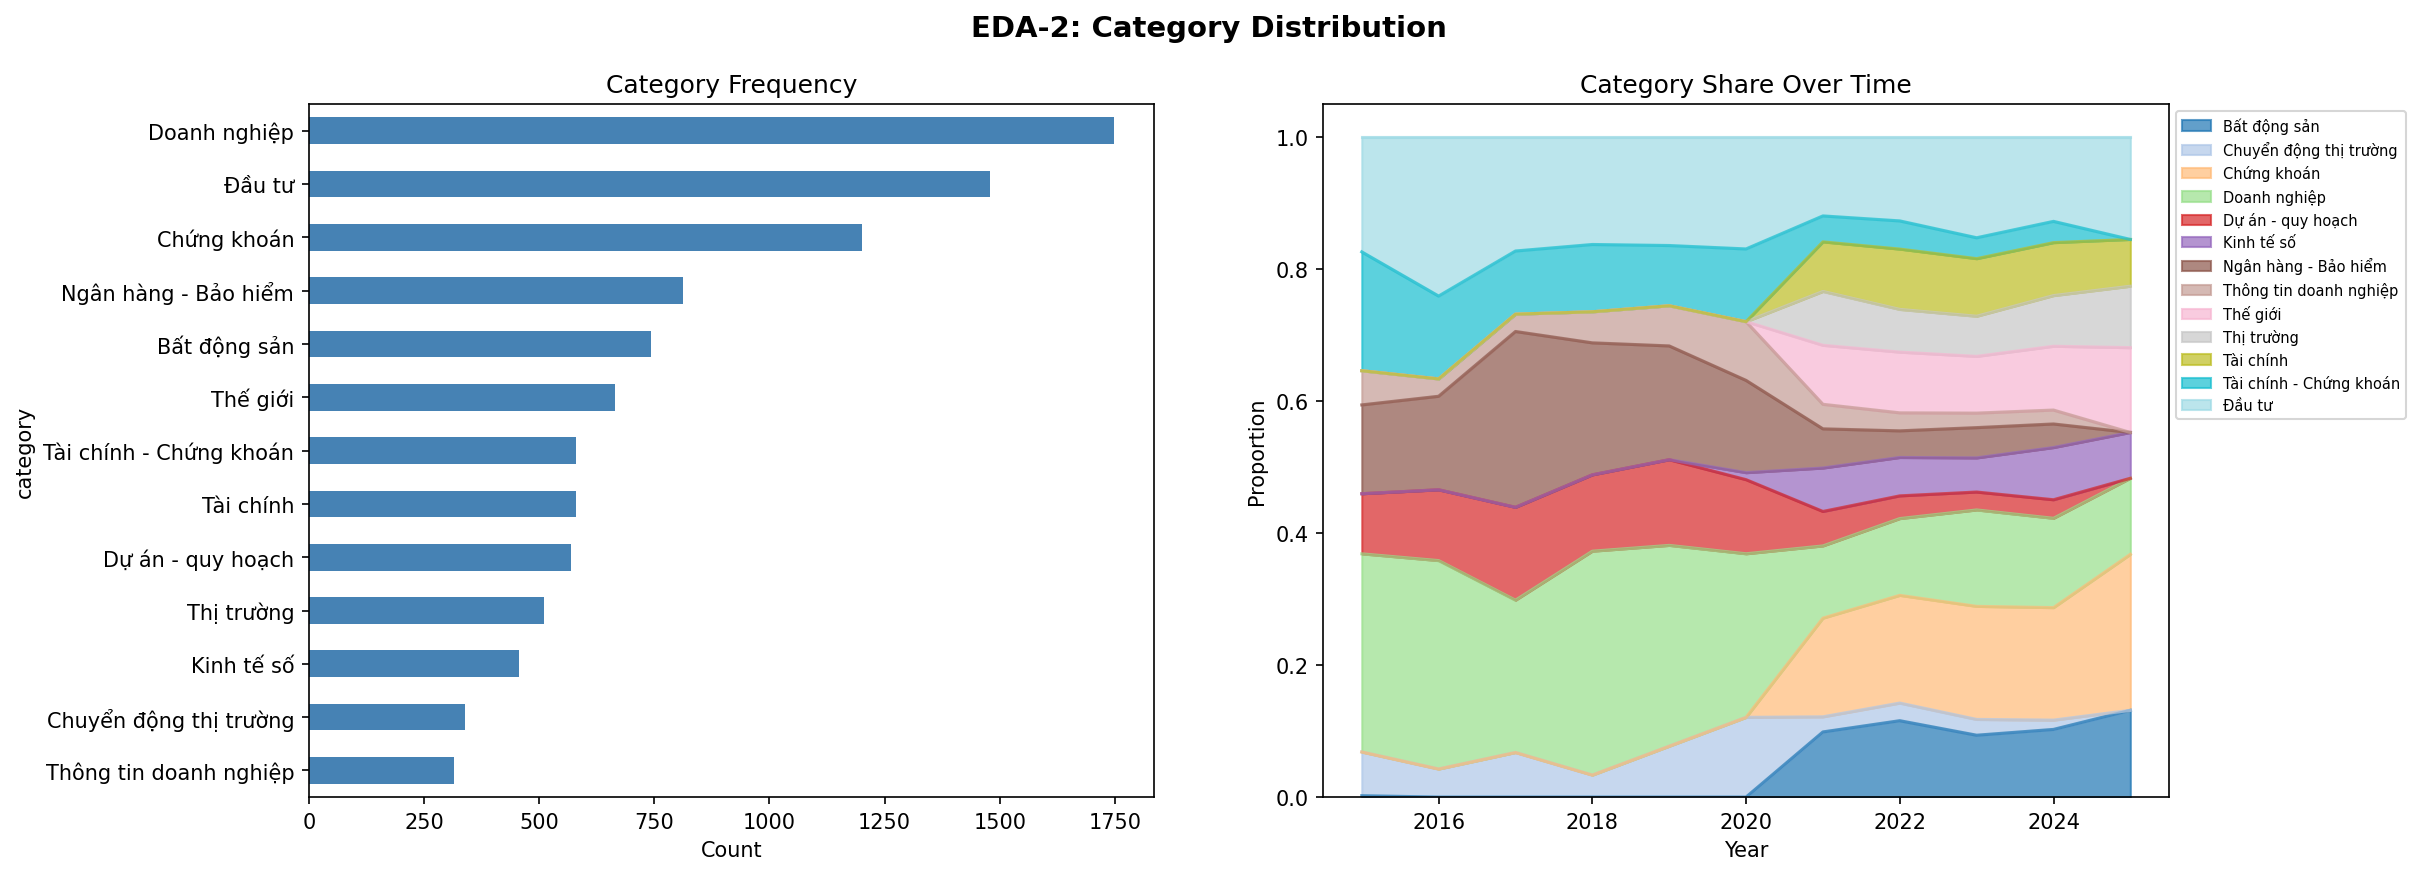

In [6]:
from src.preprocessing import eda_category

eda2 = eda_category(df, plots_dir)

print("EDA-2 Results:")
print(json.dumps(eda2, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda2_category.png'), width=900))

## Cell 5 — EDA-3: Content Length Analysis (§1.3)

[2026-05-06 16:17:40] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda3_content_length.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda3_content_length.png


EDA-3 Results:
{
  "token_length": {
    "mean": 946.8481848184819,
    "median": 934.0,
    "p90": 1470.0,
    "p99": 1893.0400000000009
  },
  "articles_exceeding_512_tokens_pct": 0.8655,
  "design_implication": "article_level chunking will truncate ~87% of articles — document as main weakness."
}


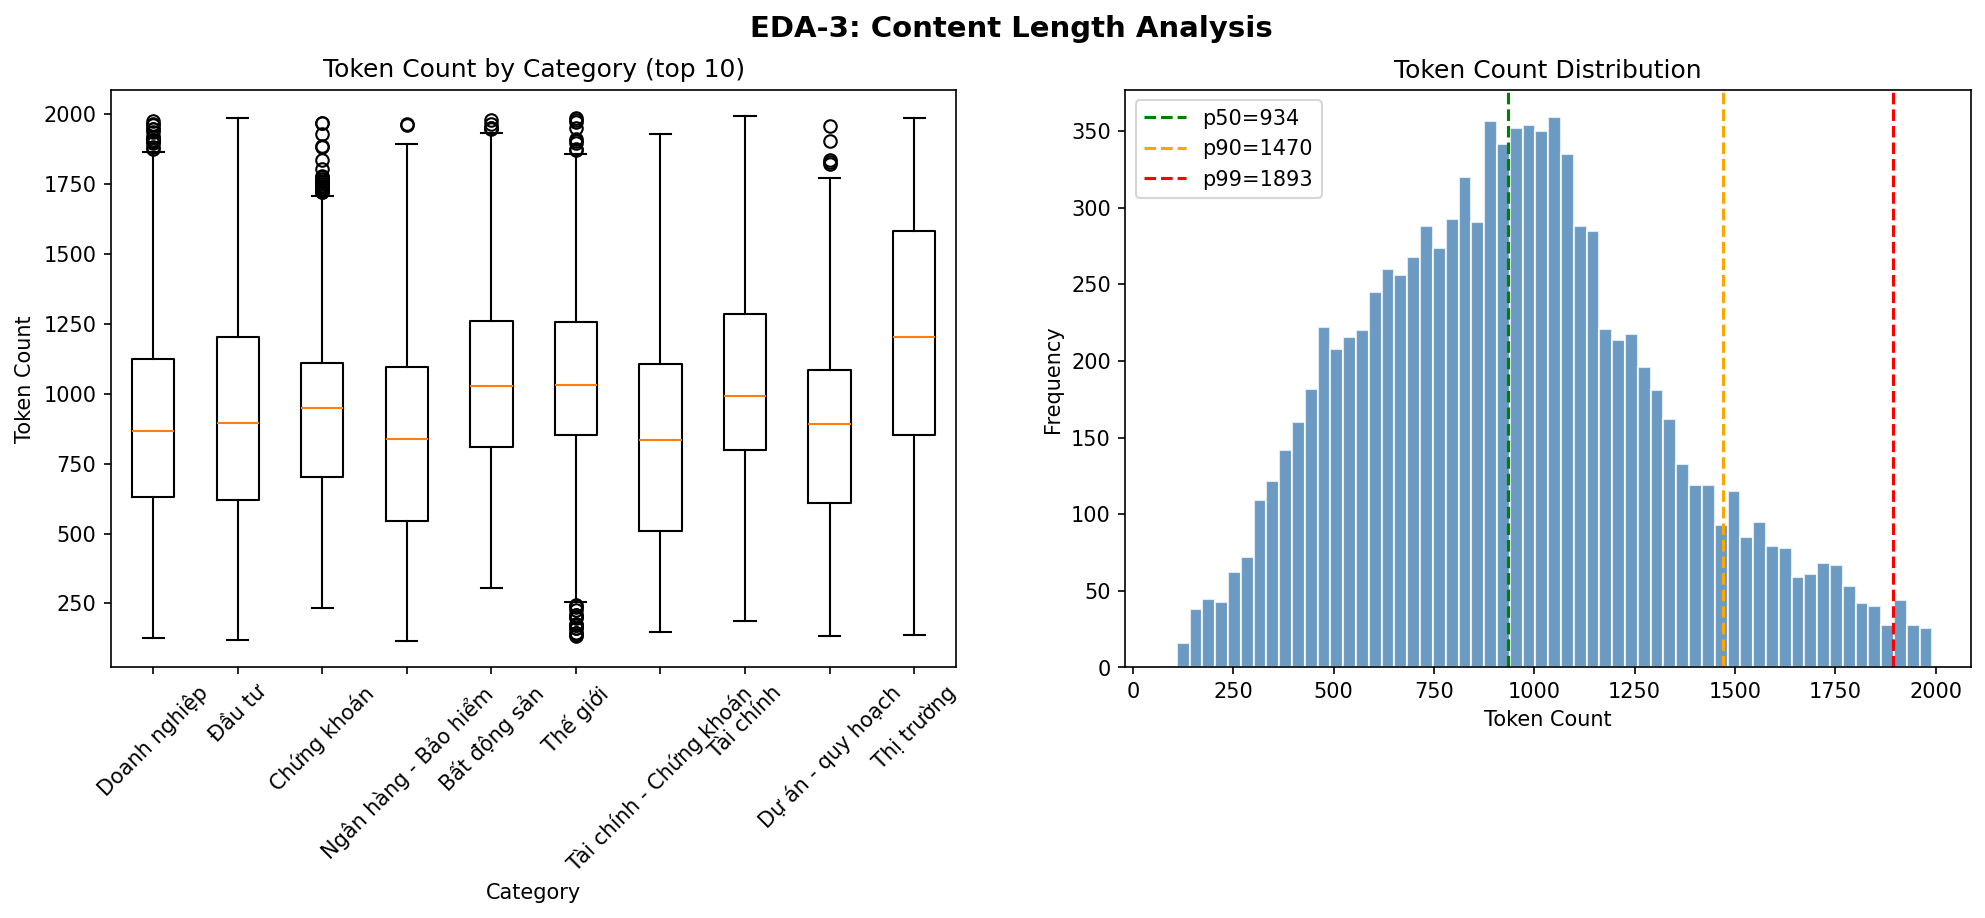

In [7]:
from src.preprocessing import eda_content_length

eda3 = eda_content_length(df, plots_dir)

print("EDA-3 Results:")
print(json.dumps(eda3, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda3_content_length.png'), width=900))

## Cell 6 — EDA-4: Tag & Keyword Analysis (§1.3)

[2026-05-06 16:17:41] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda4_tags.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda4_tags.png


EDA-4 Results:
{
  "tag_coverage_pct": 0.9801,
  "unique_tags": 19169,
  "top_10_tags": [
    "chứng khoán",
    "bất động sản",
    "thị trường",
    "đầu tư",
    "tài chính",
    "kinh tế số",
    "doanh nghiệp",
    "ngân hàng",
    "nhận định chứng khoán",
    "giá vàng hôm nay"
  ],
  "top_50_tags_for_qa_sampling": [
    "chứng khoán",
    "bất động sản",
    "thị trường",
    "đầu tư",
    "tài chính",
    "kinh tế số",
    "doanh nghiệp",
    "ngân hàng",
    "nhận định chứng khoán",
    "giá vàng hôm nay",
    "thế giới",
    "giá vàng",
    "cổ phiếu",
    "thị trường bất động sản",
    "VN-Index",
    "lãi suất",
    "digital economy",
    "TP.HCM",
    "chuyển đổi số",
    "Đà Nẵng",
    "Trung Quốc",
    "dự án",
    "chứng khoán Mỹ",
    "hạ tầng",
    "tỷ giá",
    "nông sản",
    "thị trường chứng khoán",
    "blog chứng khoán",
    "Thanh Hóa",
    "khởi nghiệp",
    "lạm phát",
    "giá dầu",
    "Giao thông",
    "chứng khoán hôm nay",
    "giá vàng thế giới",
    "t

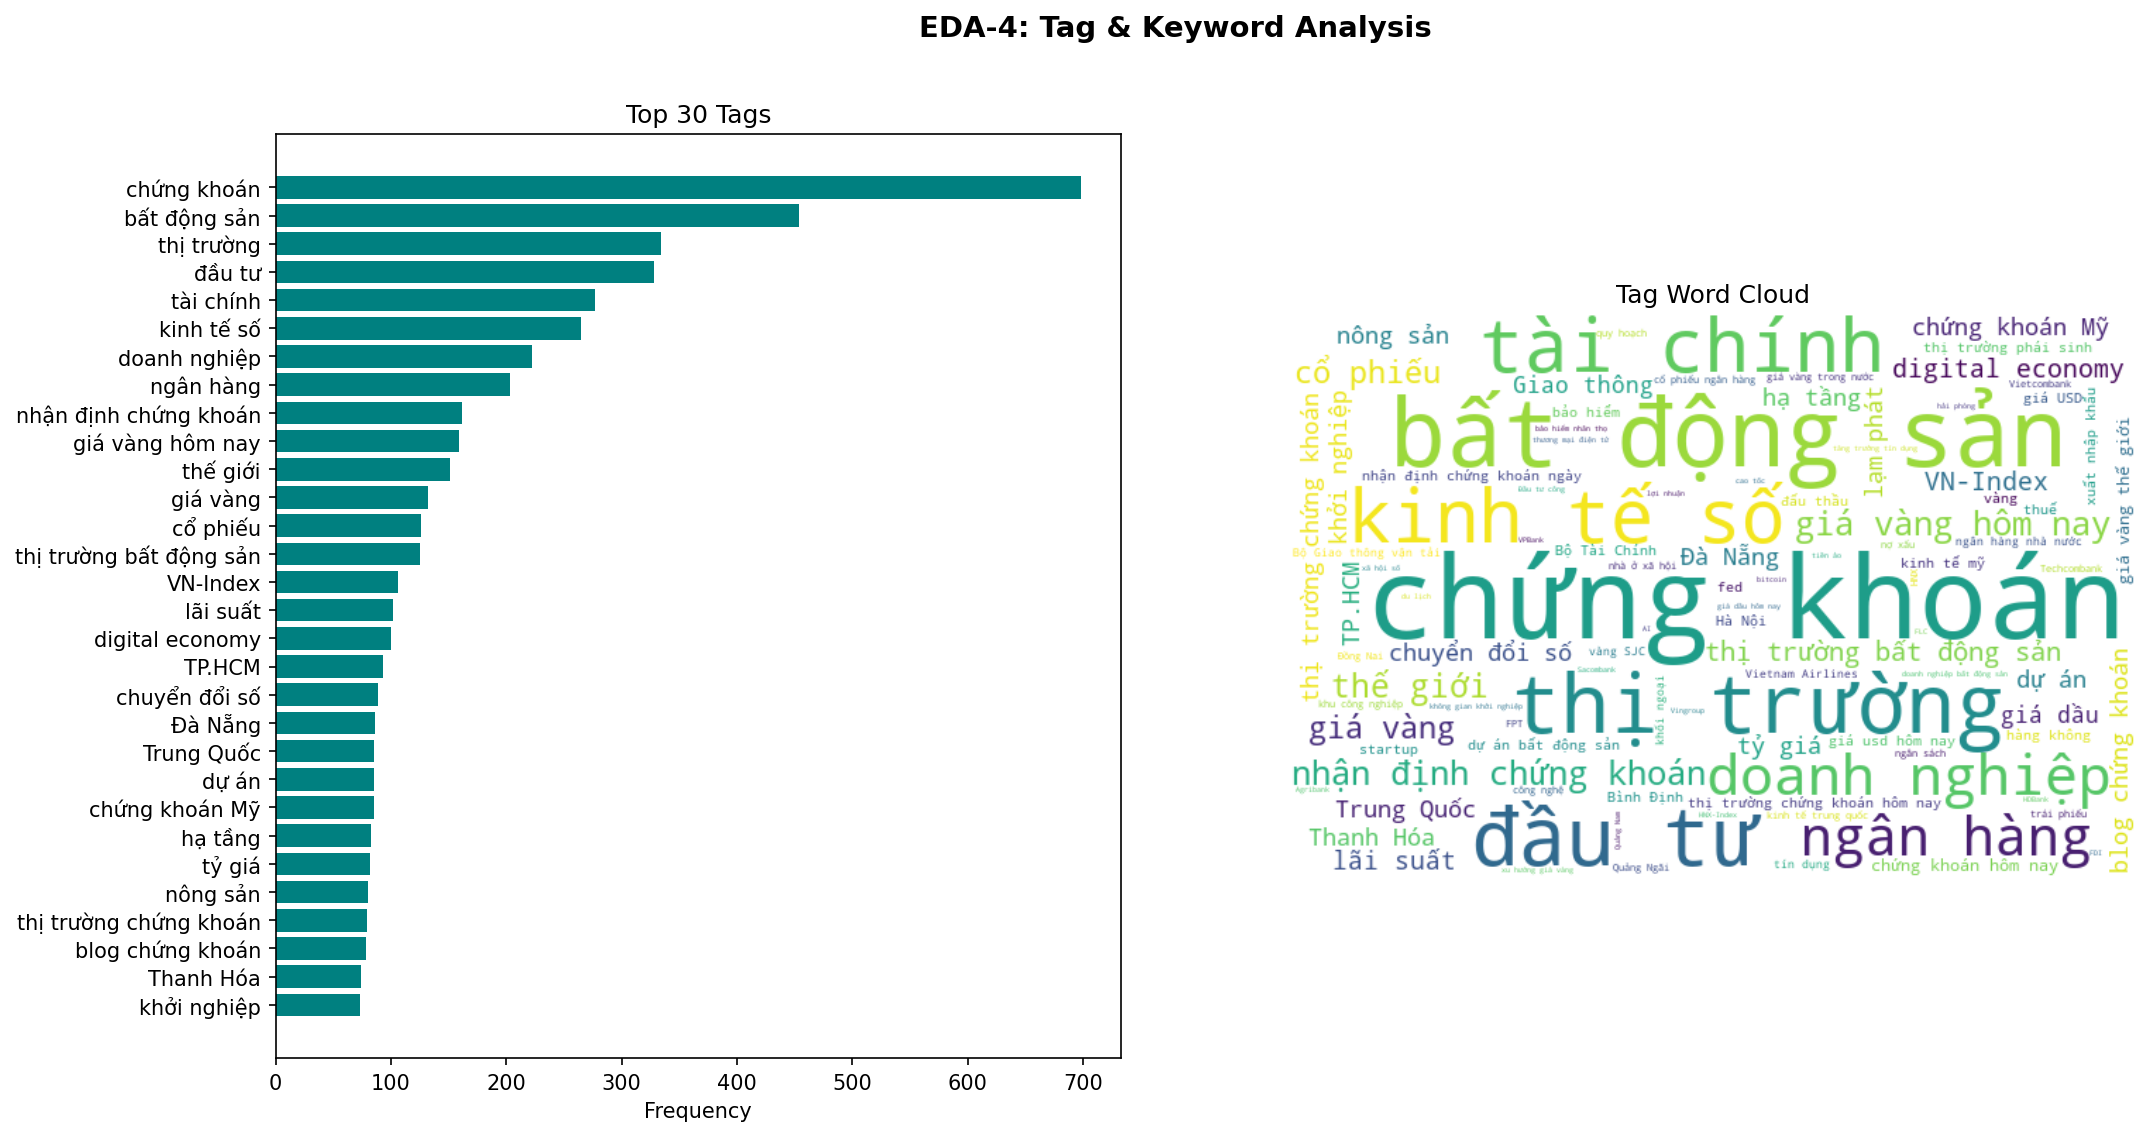

In [8]:
from src.preprocessing import eda_tags

eda4 = eda_tags(df, plots_dir)

print("EDA-4 Results:")
print(json.dumps(eda4, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda4_tags.png'), width=900))

## Cell 7 — EDA-5: Temporal Text Patterns (§1.3)

[2026-05-06 16:17:42] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda5_temporal_patterns.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda5_temporal_patterns.png


EDA-5 Results:
{
  "anomalous_yearmonths_lt5_articles": [],
  "design_implication": "Months with <5 articles may produce misleading low-recall retrieval scores — flag in evaluation notes."
}


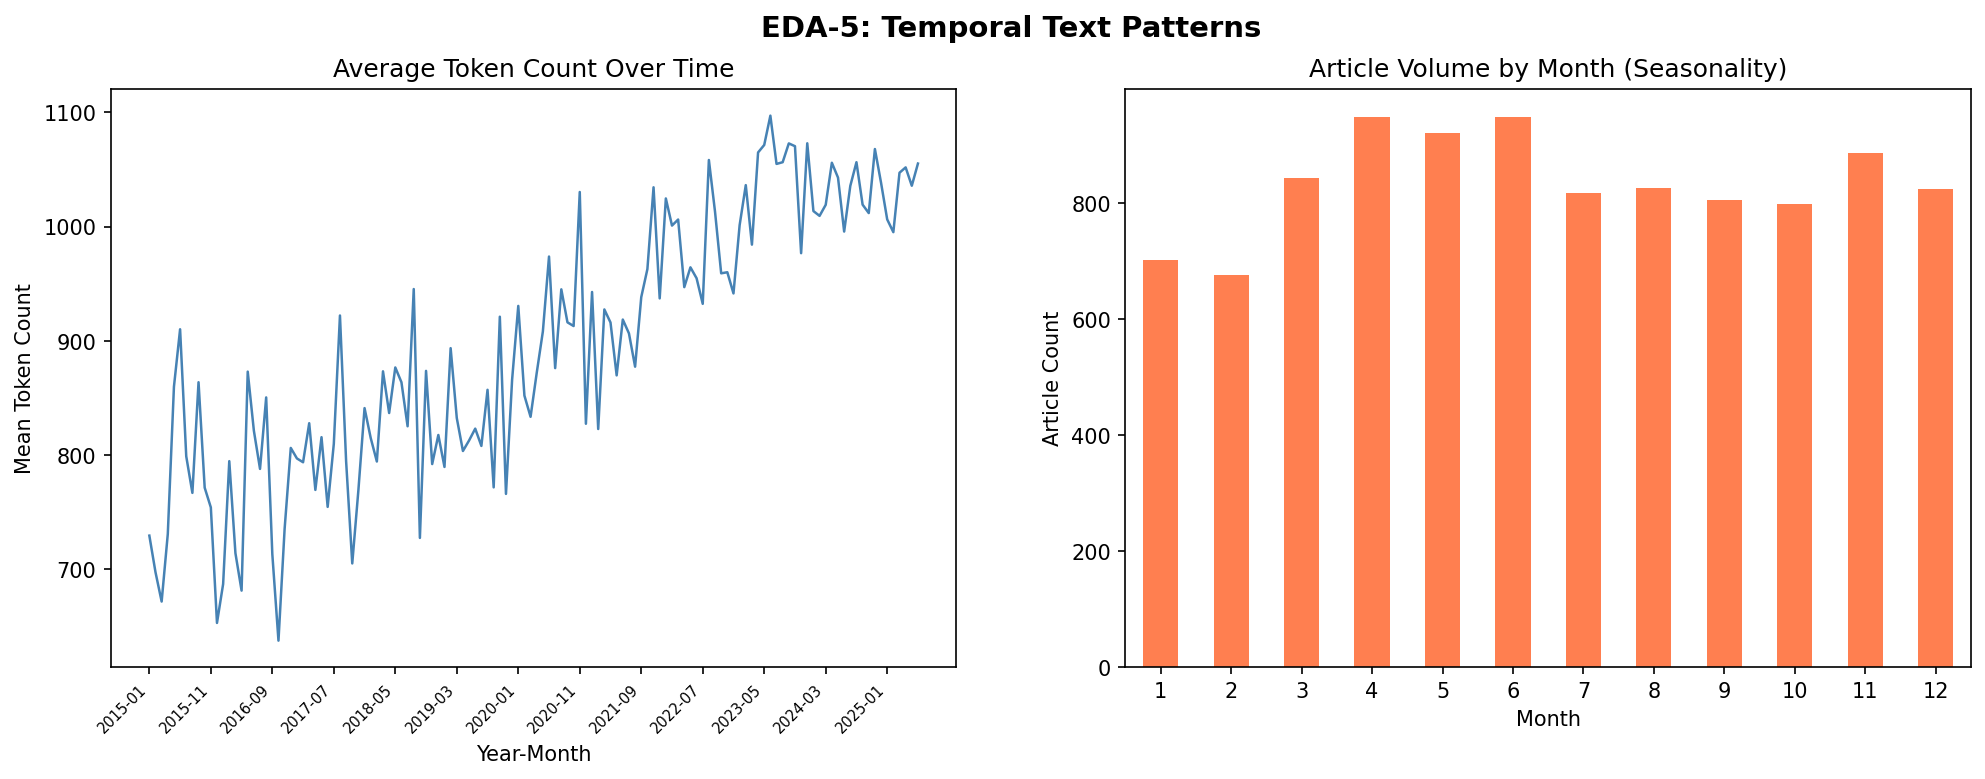

In [9]:
from src.preprocessing import eda_temporal_patterns

# EDA-3 must have already run to add token_count column
if 'token_count' not in df.columns:
    df['token_count'] = df['content_token_counts'].astype(int)

eda5 = eda_temporal_patterns(df, plots_dir)

print("EDA-5 Results:")
print(json.dumps(eda5, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda5_temporal_patterns.png'), width=900))

## Cell 8 — EDA-6: Content Duplication & Near-Duplicate Analysis (§1.3)

> Uses `datasketch` MinHash (threshold 0.85, 2000-article sample). Falls back to hash-prefix if unavailable.

[2026-05-06 16:18:19] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda6_duplication.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda6_duplication.png


EDA-6 Results:
{
  "exact_duplicates_on_content": 0,
  "near_duplicates_found": 0,
  "near_dup_detection_method": "minhash",
  "near_dup_pct": 0.0,
  "design_implication": "Near-duplicate rate <5% — no additional deduplication step needed."
}


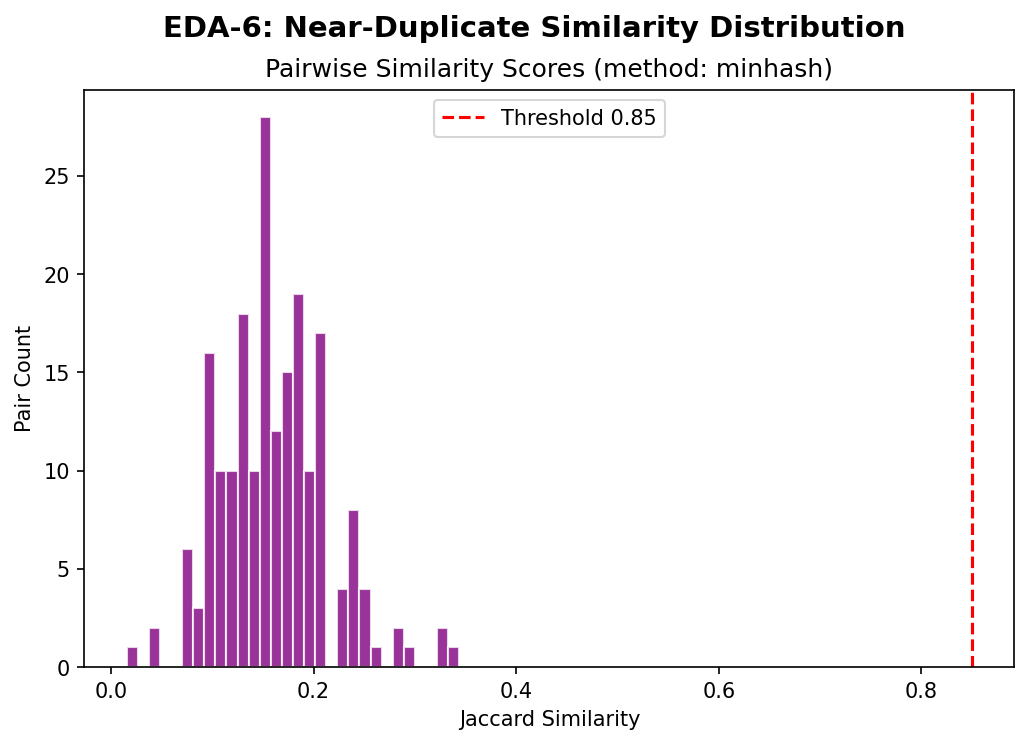

In [10]:
from src.preprocessing import eda_duplication

eda6 = eda_duplication(df, plots_dir)

print("EDA-6 Results:")
print(json.dumps(eda6, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda6_duplication.png'), width=700))

## Cell 9 — EDA-7: Vocabulary & Readability Analysis (§1.3)

[2026-05-06 16:18:35] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda7_vocabulary.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda7_vocabulary.png


EDA-7 Results:
{
  "vocab_size_min_freq5": 11815,
  "financial_term_coverage": {
    "lãi suất": 0.1501,
    "chứng khoán": 0.173,
    "cổ phiếu": 0.1827,
    "ngân hàng": 0.3061,
    "tín dụng": 0.1182,
    "đầu tư": 0.6939,
    "GDP": 0.0488,
    "lạm phát": 0.0743,
    "tỷ giá": 0.0575,
    "vốn hóa": 0.0445
  },
  "safe_query_terms_gt20pct": [
    "ngân hàng",
    "đầu tư"
  ],
  "design_implication": "Financial terms with <5% coverage are risky for retrieval evaluation; use high-coverage terms as QA anchors."
}


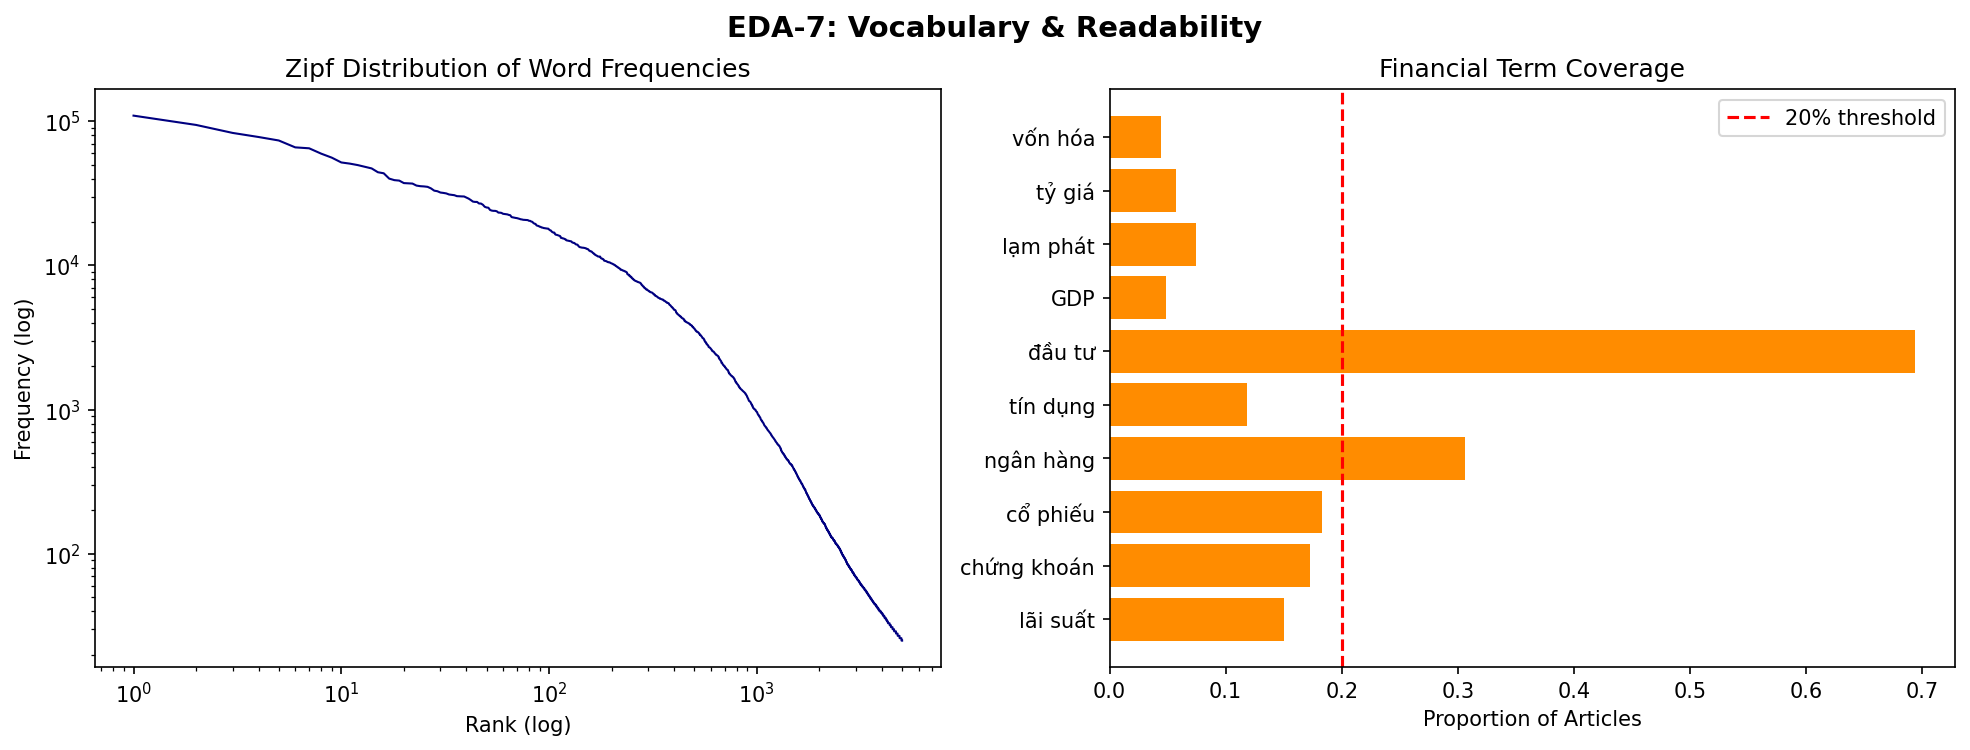

In [11]:
from src.preprocessing import eda_vocabulary

eda7 = eda_vocabulary(df, plots_dir)

print("EDA-7 Results:")
print(json.dumps(eda7, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda7_vocabulary.png'), width=900))

## Cell 10 — EDA-8: Cross-Variable Correlation Matrix (§1.3)

[2026-05-06 16:18:37] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda8_correlation.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda8_correlation.png


EDA-8 Results:
{
  "correlation_matrix_shape": [
    14,
    14
  ],
  "features_included": [
    "token_count",
    "year",
    "month",
    "ttr",
    "has_lãi_suất",
    "has_chứng_khoán",
    "has_cổ_phiếu",
    "has_ngân_hàng",
    "has_tín_dụng",
    "has_đầu_tư",
    "has_GDP",
    "has_lạm_phát",
    "has_tỷ_giá",
    "has_vốn_hóa"
  ],
  "design_implication": "Correlated financial terms can build multi-topic evaluation queries that test multi-concept retrieval."
}


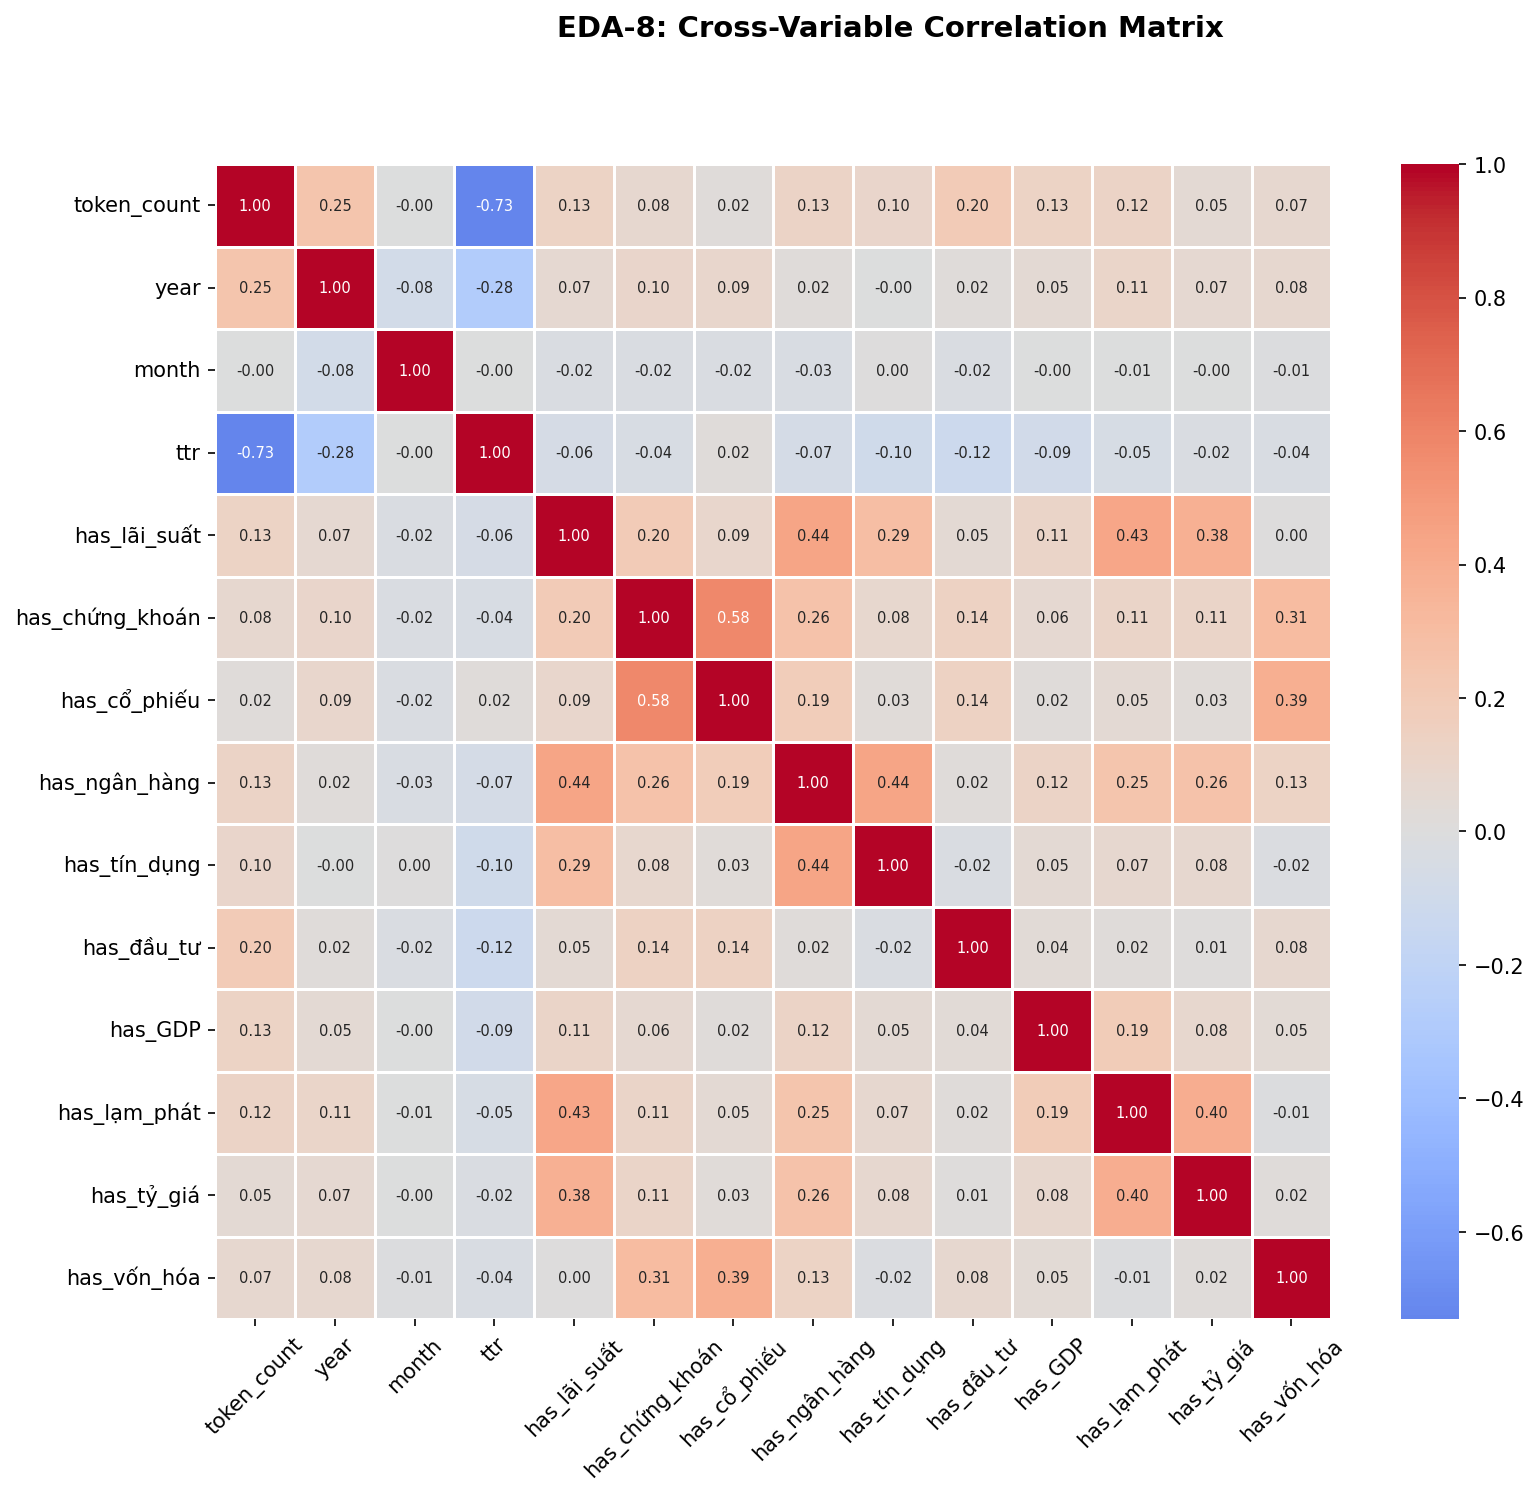

In [12]:
from src.preprocessing import eda_correlation

# Requires token_count and ttr columns from EDA-3 and EDA-7
if 'token_count' not in df.columns:
    df['token_count'] = df['content_token_counts'].astype(int)
if 'ttr' not in df.columns:
    df['ttr'] = df['content'].apply(
        lambda x: len(set(str(x).lower().split())) / max(len(str(x).split()), 1)
    )

eda8 = eda_correlation(df, plots_dir)

print("EDA-8 Results:")
print(json.dumps(eda8, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda8_correlation.png'), width=800))

## Cell 10b — EDA-9: Niche Glossary (§1.3)

[2026-05-06 16:18:38] [INFO] src.preprocessing: Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda9_niche_glossary.png
Plot saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_plots\eda9_niche_glossary.png


EDA-9 Results:
{
  "definition_articles_count": 243,
  "design_implication": "Articles containing definitions can be leveraged for terminology-specific QA pairs."
}


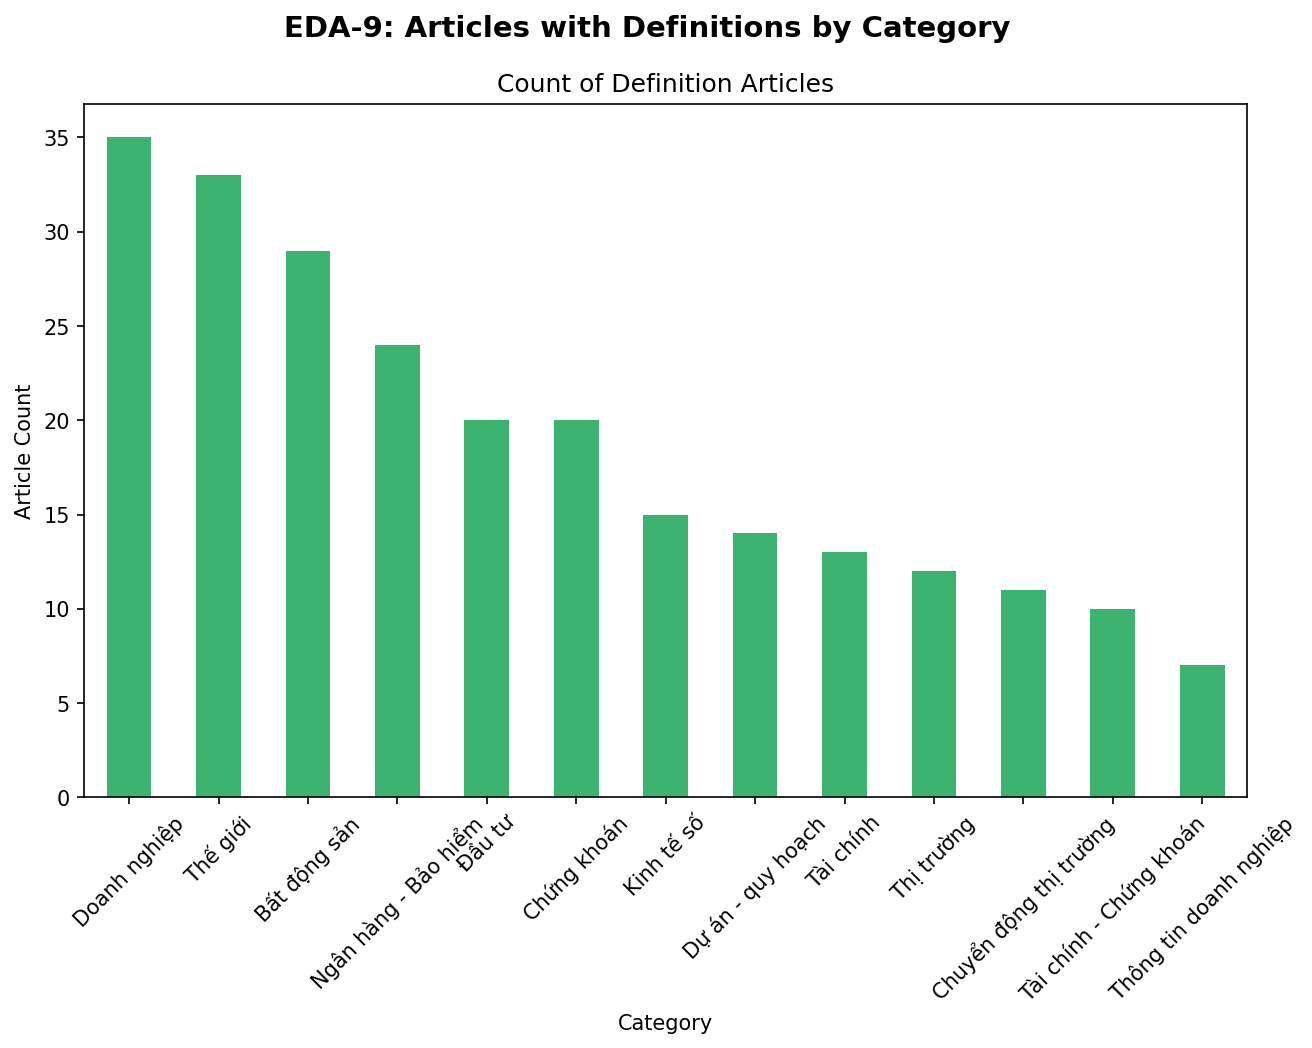

In [13]:
from src.preprocessing import eda_niche_glossary

eda9 = eda_niche_glossary(df, plots_dir)

print("EDA-9 Results:")
print(json.dumps(eda9, indent=2, ensure_ascii=False))

ipy_display(Image(filename=os.path.join(plots_dir, 'eda9_niche_glossary.png'), width=800))

## Cell 11 — Assemble EDA Report (§1.4)

In [14]:
from src.preprocessing import assemble_eda_report, save_eda_report

eda_sections = {
    'eda1': eda1, 'eda2': eda2, 'eda3': eda3, 'eda4': eda4,
    'eda5': eda5, 'eda6': eda6, 'eda7': eda7, 'eda8': eda8, 'eda9': eda9
}

eda_report = assemble_eda_report(df_raw, df, eda_sections)

report_path = resolve_path(config['data'], 'eda_report_path')
if not os.path.isabs(report_path):
    report_path = str(REPO_ROOT / report_path)

save_eda_report(eda_report, report_path)

print("\nEDA Report Summary:")
for k, v in eda_report.items():
    if not isinstance(v, dict):
        print(f"  {k}: {v}")

print(f"\nDesign Implications:")
for i, impl in enumerate(eda_report.get('design_implications', []), 1):
    print(f"  {i}. {impl}")

# Verify plot count
png_files = list(Path(plots_dir).glob('*.png'))
print(f"\nPNG plots saved: {len(png_files)}")
for p in sorted(png_files):
    print(f"  {p.name}")

[2026-05-06 16:18:38] [INFO] src.preprocessing: EDA report saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_report.json
EDA report saved: d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\eda_report.json



EDA Report Summary:
  total_documents_raw: 10000
  total_documents_clean: 9999
  dropped_rows: 1
  dead_months_lt10_articles: 0
  under_represented_categories: []
  articles_exceeding_512_tokens_pct: 0.8655
  tag_coverage_pct: 0.9801
  unique_tags: 19169
  top_10_tags: ['chứng khoán', 'bất động sản', 'thị trường', 'đầu tư', 'tài chính', 'kinh tế số', 'doanh nghiệp', 'ngân hàng', 'nhận định chứng khoán', 'giá vàng hôm nay']
  top_50_tags_for_qa_sampling: ['chứng khoán', 'bất động sản', 'thị trường', 'đầu tư', 'tài chính', 'kinh tế số', 'doanh nghiệp', 'ngân hàng', 'nhận định chứng khoán', 'giá vàng hôm nay', 'thế giới', 'giá vàng', 'cổ phiếu', 'thị trường bất động sản', 'VN-Index', 'lãi suất', 'digital economy', 'TP.HCM', 'chuyển đổi số', 'Đà Nẵng', 'Trung Quốc', 'dự án', 'chứng khoán Mỹ', 'hạ tầng', 'tỷ giá', 'nông sản', 'thị trường chứng khoán', 'blog chứng khoán', 'Thanh Hóa', 'khởi nghiệp', 'lạm phát', 'giá dầu', 'Giao thông', 'chứng khoán hôm nay', 'giá vàng thế giới', 'thị trường

## Cell 12 — Idempotent Save (§1.5)

> Saves `cleaned.parquet` (Snappy compressed). Loads from cache if already exists.

In [15]:
from src.preprocessing import save_cleaned

processed_path = resolve_path(config['data'], 'processed_path')
if not os.path.isabs(processed_path):
    processed_path = str(REPO_ROOT / processed_path)

df.to_parquet(processed_path, index=False, compression="snappy")

# Verify output
parquet_size_mb = os.path.getsize(processed_path) / 1e6
print(f"\nVerification:")
print(f"  File   : {processed_path}")
print(f"  Size   : {parquet_size_mb:.1f} MB  (expected 15–25 MB)")
print(f"  Rows   : {len(df):,}")
print(f"  Columns: {df.columns.tolist()}")

# Confirm drop log exists
drop_log_path = resolve_path(config['data'], 'drop_log_path')
if not os.path.isabs(drop_log_path):
    drop_log_path = str(REPO_ROOT / drop_log_path)
if os.path.exists(drop_log_path):
    drop_df = pd.read_csv(drop_log_path)
    print(f"  Drop log: {len(drop_df)} entries")

print("\n✅ Phase 1 complete")


Verification:
  File   : d:\000MINHTHONG\Junior - Semester II\TDM & A\FinalProject\finance-news\implementation\data\processed\cleaned.parquet
  Size   : 26.0 MB  (expected 15–25 MB)
  Rows   : 9,999
  Columns: ['url', 'title', 'time', 'category', 'content', 'tags', 'content_token_counts', 'year', 'month', 'yearmonth', 'doc_id', 'source', 'tickers', 'is_historical', 'numerical_density', 'entities', 'token_count', 'word_count', 'char_count', 'ttr', 'has_lãi_suất', 'has_chứng_khoán', 'has_cổ_phiếu', 'has_ngân_hàng', 'has_tín_dụng', 'has_đầu_tư', 'has_GDP', 'has_lạm_phát', 'has_tỷ_giá', 'has_vốn_hóa']
  Drop log: 1 entries

✅ Phase 1 complete
